In [1]:
!pip install tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import tensorflow as tf
import os
import time

# 1. Download the dataset
print("Downloading Edges2Shoes dataset... This might take a few minutes.")
dataset_url = "https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz"
path_to_zip = tf.keras.utils.get_file('edges2shoes.tar.gz', origin=dataset_url, extract=True)
PATH = os.path.join(os.path.dirname(path_to_zip), 'edges2shoes/')

# 2. Load and Split the Paired Images
def load_and_split(image_file):
    # Read and decode the image
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)

    # Calculate the midpoint to split the 256x512 image
    w = tf.shape(image)[1]
    w = w // 2

    # Left half is the edge map, right half is the real shoe
    input_image = image[:, :w, :]
    real_image = image[:, w:, :]

    # Convert to float32
    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)

    return input_image, real_image

# 3. Normalize the Images
def resize_and_normalize(input_image, real_image):
    # Resize to 256x256 (in case of slight dimension variations)
    input_image = tf.image.resize(input_image, [256, 256])
    real_image = tf.image.resize(real_image, [256, 256])

    # Normalize images to [-1, 1] to match the Tanh activation in the Generator
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1

    return input_image, real_image

def load_image_train(image_file):
    input_image, real_image = load_and_split(image_file)
    return resize_and_normalize(input_image, real_image)

2165283376/2165283376 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step


In [14]:
import glob

# Hyperparameters
BUFFER_SIZE = 400
BATCH_SIZE = 1

# 1. Grab ALL the file paths in the train folder
all_train_files = glob.glob(PATH + 'train/*.jpg')

# 2. Slice the list to keep only 50% (or change the math to // 10 for 10%)
reduced_size = len(all_train_files) // 10
reduced_train_files = all_train_files[:reduced_size]

print(f"Original dataset size: {len(all_train_files)} images")
print(f"Reduced dataset size for training: {len(reduced_train_files)} images")

# 3. Create the Training Dataset from the reduced list
train_dataset = tf.data.Dataset.from_tensor_slices(reduced_train_files)
train_dataset = train_dataset.map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# 4. Create the Testing Dataset (we can leave this whole, or reduce it too)
test_dataset = tf.data.Dataset.list_files(PATH + 'val/*.jpg')
test_dataset = test_dataset.map(load_image_train)
test_dataset = test_dataset.batch(BATCH_SIZE)

print("Reduced dataset successfully loaded and prepared!")

Original dataset size: 49825 images
Reduced dataset size for training: 4982 images
Reduced dataset successfully loaded and prepared!


In [15]:
# --- TASK 2: U-NET GENERATOR ---
def downsample(filters, size, apply_batchnorm=True):
    """Downsampling blocks with convolution [cite: 27]"""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    """Upsampling blocks [cite: 28]"""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                      kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def build_unet_generator():
    """Builds the U-Net Generator with skip connections [cite: 9, 28]"""
    inputs = layers.Input(shape=[256, 256, 3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (bs, 128, 128, 64)
        downsample(128, 4),                       # (bs, 64, 64, 128)
        downsample(256, 4),                       # (bs, 32, 32, 256)
    ]

    up_stack = [
        upsample(128, 4),                         # (bs, 64, 64, 128)
        upsample(64, 4),                          # (bs, 128, 128, 64)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  kernel_initializer=initializer, activation='tanh') # (bs, 256, 256, 3)

    x = inputs
    skips = []
    # Downsampling
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections [cite: 16]
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

generator = build_unet_generator()

In [16]:
# --- TASK 3: PATCHGAN DISCRIMINATOR ---
def build_patchgan_discriminator():
    """Builds the PatchGAN Discriminator [cite: 10]"""
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')

    # Concatenate input edge map and target image
    x = layers.concatenate([inp, tar])

    # Convolutional layers [cite: 30]
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)

    zero_pad1 = layers.ZeroPadding2D()(down2)
    conv = layers.Conv2D(256, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    # Output patch-level authenticity map (no fully connected layers) [cite: 31, 32]
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

discriminator = build_patchgan_discriminator()

Starting training...
Epoch 1/5
.................................................


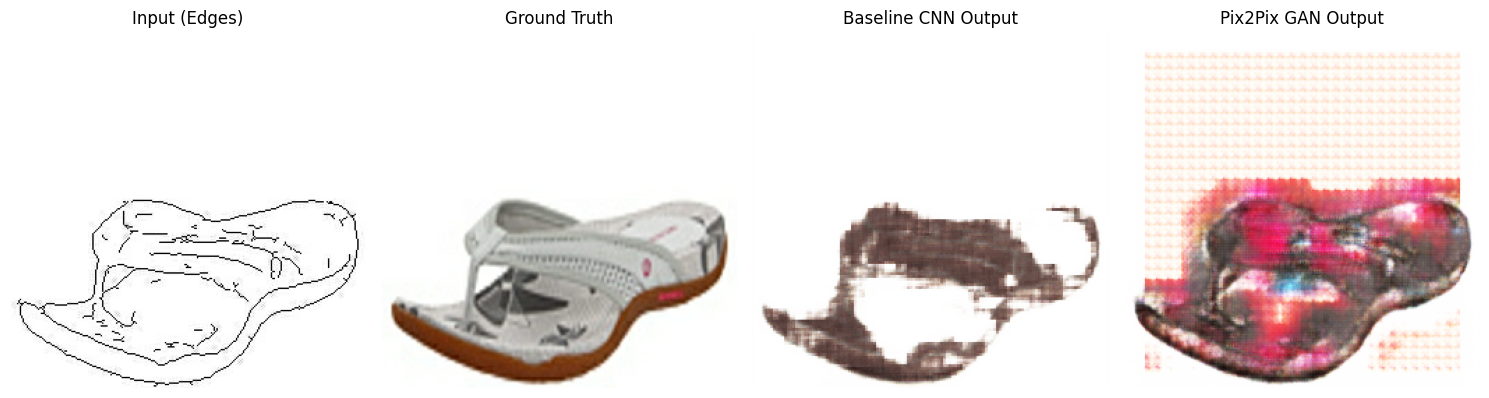

Time taken for epoch 1 is 208.31 sec

Epoch 2/5
.................................................


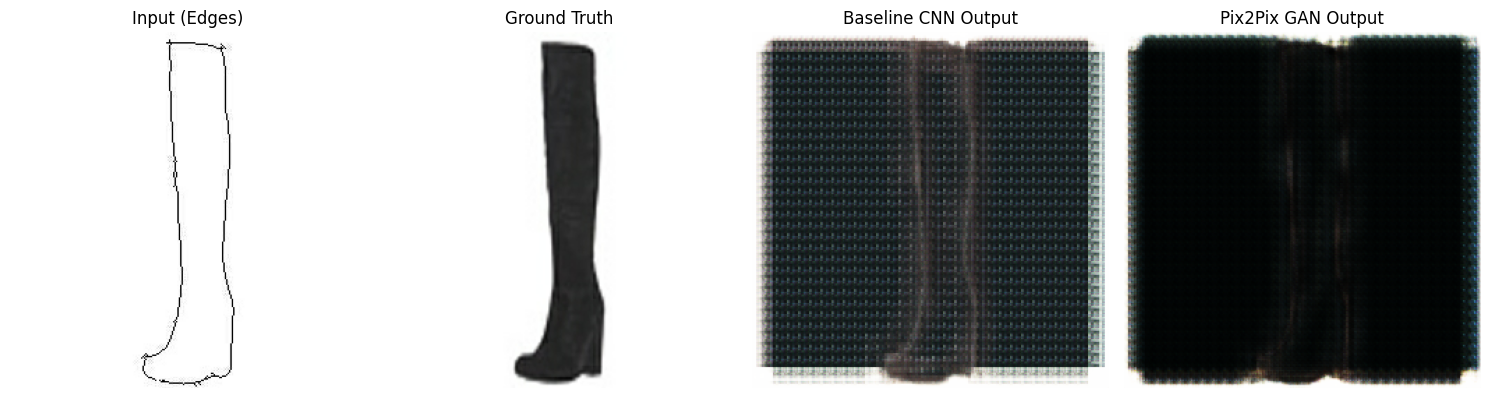

Time taken for epoch 2 is 206.99 sec

Epoch 3/5
.................................................


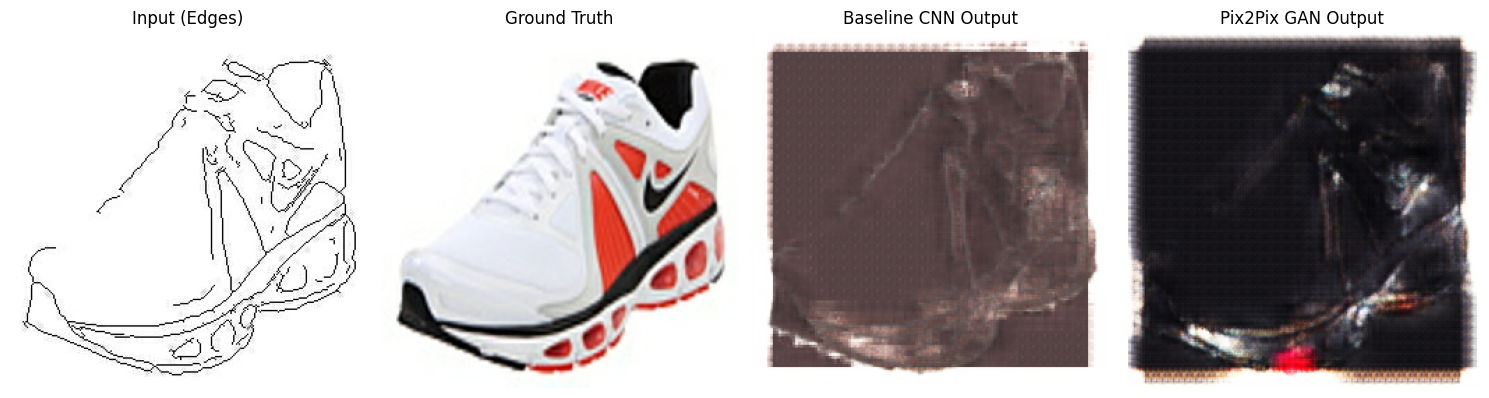

Time taken for epoch 3 is 208.96 sec

Epoch 4/5
.................................................


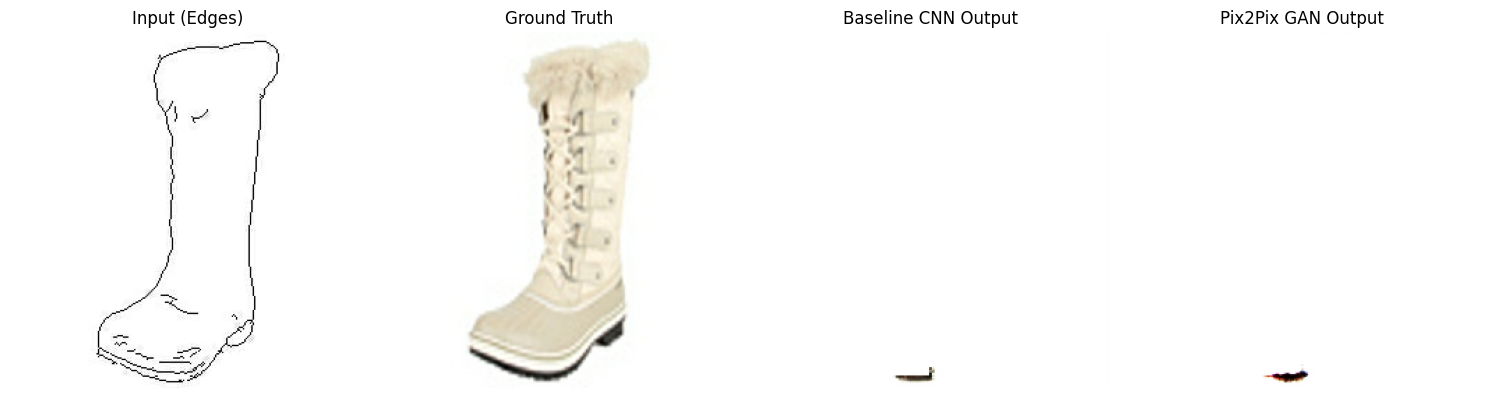

Time taken for epoch 4 is 208.35 sec

Epoch 5/5
.................................................


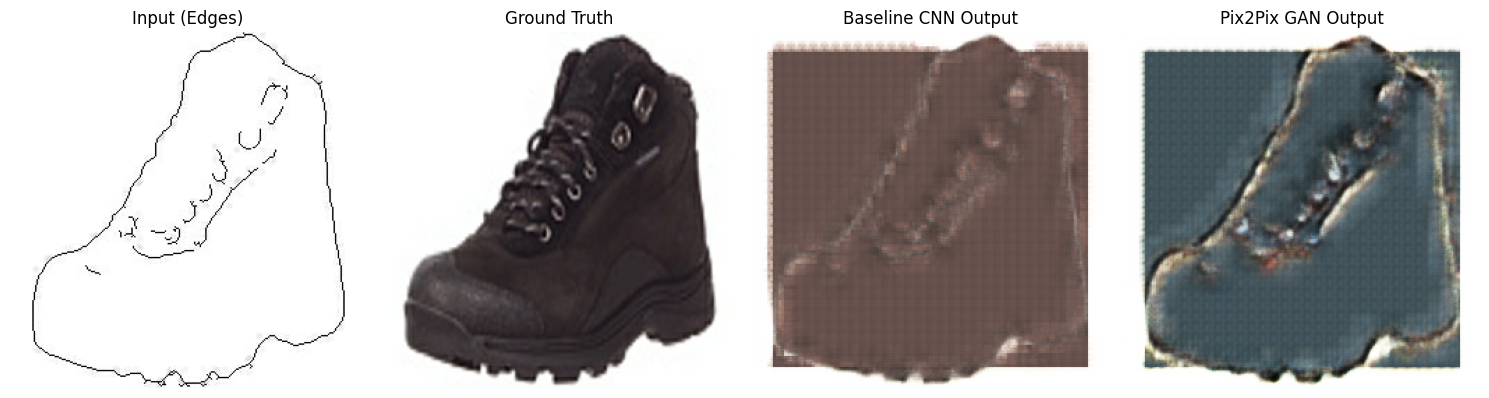

Time taken for epoch 5 is 208.30 sec



In [18]:
EPOCHS = 5 # Start with 5 just to see the gray boxes change
LAMBDA = 100 # Define LAMBDA for L1 loss weight

# --- TASK 4: PIX2PIX GAN TRAINING COMPONENTS ---

# Define optimizers
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Loss functions
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    fake_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    # L1 loss
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss

@tf.function
def train_step_pix2pix(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

# --- TASK 5: PERFORMANCE COMPARISON (moved from N4upI29XW44n) ---

# 1. Setup Baseline CNN
baseline_cnn = build_unet_generator() # Same Encoder-Decoder architecture
baseline_optimizer = tf.keras.optimizers.Adam(2e-4)

@tf.function
def train_step_baseline(input_image, target):
    """Trains the baseline CNN using only L1 reconstruction loss."""
    with tf.GradientTape() as tape:
        prediction = baseline_cnn(input_image, training=True)
        # Baseline uses NO adversarial loss, only L1
        loss = tf.reduce_mean(tf.abs(target - prediction))

    gradients = tape.gradient(loss, baseline_cnn.trainable_variables)
    baseline_optimizer.apply_gradients(zip(gradients, baseline_cnn.trainable_variables))

# 2. Mock Training Loop (1 step) to initialize weights
# Get one batch from the training dataset for initialization
example_train_input, example_train_target = next(iter(train_dataset))
train_step_pix2pix(example_train_input, example_train_target)
train_step_baseline(example_train_input, example_train_target)

# 3. Visualization / Comparison
def display_comparison(gen_model, baseline_model, test_in, test_tar):
    # Generate predictions
    pix2pix_pred = gen_model(test_in, training=False)
    baseline_pred = baseline_model(test_in, training=False)

    plt.figure(figsize=(15, 5))
    display_list = [test_in[0], test_tar[0], baseline_pred[0], pix2pix_pred[0]]
    titles = ['Input (Edges)', 'Ground Truth', 'Baseline CNN Output', 'Pix2Pix GAN Output']

    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        # Rescale from [-1, 1] to [0, 1] to display properly
        plt.imshow(display_list[i].numpy() * 0.5 + 0.5)
        plt.axis('off')

    # We use block=True to ensure the window stays open on your machine
    plt.tight_layout()
    plt.show(block=True)


print("Starting training...")
for epoch in range(EPOCHS):
    start = time.time()
    print(f"Epoch {epoch+1}/{EPOCHS}")

    # Train over the dataset batches
    for n, (input_image, target) in train_dataset.enumerate():
        # Train Pix2Pix (Task 4)
        train_step_pix2pix(input_image, target)

        # Train Baseline CNN (Task 5)
        train_step_baseline(input_image, target)

        # Print a dot every 100 steps so you know it hasn't frozen
        if (n+1) % 100 == 0:
            print('.', end='', flush=True)
    print()

    # Show the comparison at the end of every epoch using your test dataset
    for example_input, example_target in test_dataset.take(1):
        display_comparison(generator, baseline_cnn, example_input, example_target)

    print(f'Time taken for epoch {epoch+1} is {time.time()-start:.2f} sec\n')


Displaying comparison between Baseline CNN and Pix2Pix...


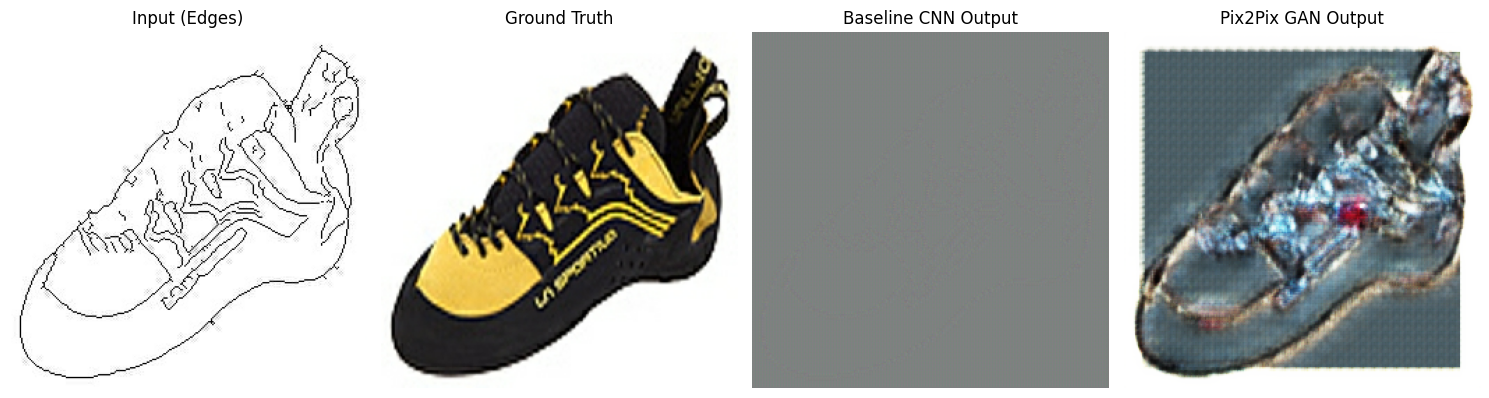

In [19]:
# --- TASK 5: PERFORMANCE COMPARISON ---

# 1. Setup Baseline CNN [cite: 42]
baseline_cnn = build_unet_generator() # Same Encoder-Decoder architecture
baseline_optimizer = tf.keras.optimizers.Adam(2e-4)

@tf.function
def train_step_baseline(input_image, target):
    """Trains the baseline CNN using only L1 reconstruction loss."""
    with tf.GradientTape() as tape:
        prediction = baseline_cnn(input_image, training=True)
        # Baseline uses NO adversarial loss, only L1
        loss = tf.reduce_mean(tf.abs(target - prediction))

    gradients = tape.gradient(loss, baseline_cnn.trainable_variables)
    baseline_optimizer.apply_gradients(zip(gradients, baseline_cnn.trainable_variables))

# 2. Mock Training Loop (1 step) to initialize weights
# Get one batch from the training dataset for initialization
example_train_input, example_train_target = next(iter(train_dataset))
train_step_pix2pix(example_train_input, example_train_target)
train_step_baseline(example_train_input, example_train_target)

# 3. Visualization / Comparison [cite: 41]
def display_comparison(gen_model, baseline_model, test_in, test_tar):
    # Generate predictions
    pix2pix_pred = gen_model(test_in, training=False)
    baseline_pred = baseline_model(test_in, training=False)

    plt.figure(figsize=(15, 5))
    display_list = [test_in[0], test_tar[0], baseline_pred[0], pix2pix_pred[0]]
    titles = ['Input (Edges)', 'Ground Truth', 'Baseline CNN Output', 'Pix2Pix GAN Output']

    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        # Rescale from [-1, 1] to [0, 1] to display properly
        plt.imshow(display_list[i].numpy() * 0.5 + 0.5)
        plt.axis('off')

    # We use block=True to ensure the window stays open on your machine
    plt.tight_layout()
    plt.show(block=True)

# Execute the comparison
print("Displaying comparison between Baseline CNN and Pix2Pix...")
# Get one batch from the test dataset for initial comparison
example_test_input, example_test_target = next(iter(test_dataset))
display_comparison(generator, baseline_cnn, example_test_input, example_test_target)
